In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Hospital_Data.csv")

In [3]:
df.head()

,Hospital Name,Location,Department,Doctors Count,Patients Count,Admission Date,Discharge Date,Medical Expenses
0,Wellness Clinic,Chennai,Orthopedics,47,182,13-12-2023,14-12-2023,31364.88
1,Fortis Care,Pune,ENT,15,51,29-12-2023,09-01-2024,47280.19
2,Wellness Clinic,Ahmedabad,Pediatrics,20,120,07-10-2023,21-10-2023,28574.72
3,Heritage Hospital,Hyderabad,Urology,8,172,29-04-2023,11-05-2023,7000.83
4,City Hospital,Kolkata,Gynecology,35,76,10-02-2023,12-02-2023,47210.46


In [4]:
df.tail()

,Hospital Name,Location,Department,Doctors Count,Patients Count,Admission Date,Discharge Date,Medical Expenses
95,Wellness Clinic,Bangalore,Gynecology,28,126,29-11-2023,10-12-2023,21065.59
96,Heritage Hospital,Jaipur,General Medicine,26,169,18-02-2023,19-02-2023,41677.34
97,Healing Touch,Bangalore,Oncology,40,193,01-11-2023,15-11-2023,47625.70
98,Metro Hospital,Lucknow,Neurology,42,163,19-05-2023,26-05-2023,8684.16
99,Healing Touch,Bangalore,Urology,14,37,09-12-2023,15-12-2023,17213.05


In [5]:
df.shape

(100, 8)

In [6]:
df.columns

Index(['Hospital Name', 'Location', 'Department', 'Doctors Count',
       'Patients Count', 'Admission Date', 'Discharge Date',
       'Medical Expenses'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Hospital Name     100 non-null    str    
 1   Location          100 non-null    str    
 2   Department        100 non-null    str    
 3   Doctors Count     100 non-null    int64  
 4   Patients Count    100 non-null    int64  
 5   Admission Date    100 non-null    str    
 6   Discharge Date    100 non-null    str    
 7   Medical Expenses  100 non-null    float64
dtypes: float64(1), int64(2), str(5)
memory usage: 6.4 KB


In [8]:
df.describe()

,Doctors Count,Patients Count,Medical Expenses
count,100.000000,100.000000,100.000000
mean,26.710000,93.470000,27173.110600
std,13.248438,48.167942,14001.995544
min,5.000000,20.000000,2854.220000
25%,15.000000,56.750000,14688.322500
50%,27.500000,84.500000,26320.945000
75%,38.250000,131.500000,40741.427500
max,49.000000,198.000000,49955.410000


## Data Cleaning

check missing values

In [9]:
df.isnull().sum()

Hospital Name       0
Location            0
Department          0
Doctors Count       0
Patients Count      0
Admission Date      0
Discharge Date      0
Medical Expenses    0
dtype: int64

Check duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

Remove duplicates

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

## Hospital Analysis

 Q1. Which hospital has the most patients?

In [20]:
Hospital_Patients = df.groupby("Hospital Name")["Patients Count"].sum()


In [21]:
Hospital_Patients.sort_values(
    ascending=False
)

Hospital Name
Apollo Health            1192
Heritage Hospital        1179
Metro Hospital           1121
Healing Touch            1059
Global Medicare           986
Fortis Care               895
Green Valley Hospital     853
City Hospital             843
Wellness Clinic           713
Sunrise Medical           506
Name: Patients Count, dtype: int64

Q2. Which hospital has the highest expenses?

In [22]:
Hospital_Expenses = df.groupby(
    "Hospital Name"
)["Medical Expenses"].sum()

Hospital_Expenses.sort_values(
    ascending=False
)

Hospital Name
Healing Touch            352178.06
City Hospital            347988.44
Fortis Care              337677.36
Global Medicare          329739.45
Metro Hospital           314786.05
Apollo Health            277335.09
Sunrise Medical          233050.93
Heritage Hospital        186899.03
Wellness Clinic          175467.82
Green Valley Hospital    162188.83
Name: Medical Expenses, dtype: float64

## Location Analysis

Patients by location

In [23]:
location_patients = df.groupby(
    "Location"
)["Patients Count"].sum()

location_patients.sort_values(
    ascending=False
)

Location
Jaipur       1505
Ahmedabad    1467
Lucknow      1264
Hyderabad    1261
Bangalore     955
Chennai       840
Kolkata       596
Pune          555
Mumbai        483
Delhi         421
Name: Patients Count, dtype: int64

## Department Analysis

1. Patients by department

In [24]:
department_patients = df.groupby(
    "Department"
)["Patients Count"].sum()

department_patients.sort_values(
    ascending=False
)

Department
Urology             1766
Neurology           1229
ENT                 1064
Pediatrics           993
Dermatology          978
Oncology             770
Orthopedics          762
Gynecology           678
General Medicine     563
Cardiology           544
Name: Patients Count, dtype: int64

2. Expenses by department

In [26]:
department_expenses = df.groupby(
    "Department"
)["Medical Expenses"].sum()

department_expenses.sort_values(
    ascending=False
)

Department
Urology             433418.49
Neurology           321397.88
Dermatology         306141.44
ENT                 302214.66
Pediatrics          270564.92
Oncology            262137.49
Orthopedics         245868.84
Gynecology          238165.44
General Medicine    185481.08
Cardiology          151920.82
Name: Medical Expenses, dtype: float64

## Doctors & Patients Analysis

Patient-to-Doctor Ratio

In [28]:
df["Patient Doctor Ratio"] = (
    df["Patients Count"] /
    df["Doctors Count"]
)


In [29]:
df[[
    "Hospital Name",
    "Department",
    "Patient Doctor Ratio"
]]

,Hospital Name,Department,Patient Doctor Ratio
0,Wellness Clinic,Orthopedics,3.872340
1,Fortis Care,ENT,3.400000
2,Wellness Clinic,Pediatrics,6.000000
3,Heritage Hospital,Urology,21.500000
4,City Hospital,Gynecology,2.171429
...,...,...,...
95,Wellness Clinic,Gynecology,4.500000
96,Heritage Hospital,General Medicine,6.500000
97,Healing Touch,Oncology,4.825000
98,Metro Hospital,Neurology,3.880952


## Medical Expenses


1.Total medical expenses

In [30]:
total_expenses = df["Medical Expenses"].sum()

print("Total Medical Expenses:", total_expenses)

Total Medical Expenses: 2717311.06


2.Average medical expenses

In [31]:
Average_Expenses = df["Medical Expenses"].mean()
print("Average Medical Expense:", Average_Expenses)

Average Medical Expense: 27173.1106


3. Expense per patient

In [32]:
df["Expense Per Patient"] = (
    df["Medical Expenses"] /
    df["Patients Count"]
)

In [33]:
df[[
    "Hospital Name",
    "Patients Count",
    "Expense Per Patient"
]]

,Hospital Name,Patients Count,Expense Per Patient
0,Wellness Clinic,182,172.334505
1,Fortis Care,51,927.062549
2,Wellness Clinic,120,238.122667
3,Heritage Hospital,172,40.702500
4,City Hospital,76,621.190263
...,...,...,...
95,Wellness Clinic,126,167.187222
96,Heritage Hospital,169,246.611479
97,Healing Touch,193,246.765285
98,Metro Hospital,163,53.277055


## Admission & Discharge Analysis

In [35]:
df["Admission Date"] = pd.to_datetime(
    df["Admission Date"]
)

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"]
)

In [36]:
df["Length of Stay"] = (
    df["Discharge Date"] -
    df["Admission Date"]
).dt.days

In [37]:
print(
    "Average Length of Stay:",
    df["Length of Stay"].mean()
)

Average Length of Stay: 7.95


## Visualization

1️. Patients by Hospital

In [38]:
Hospital_Patients = df.groupby("Hospital Name")["Patients Count"].sum()

In [41]:
Hospital_Patients = Hospital_Patients.sort_values(ascending=False)

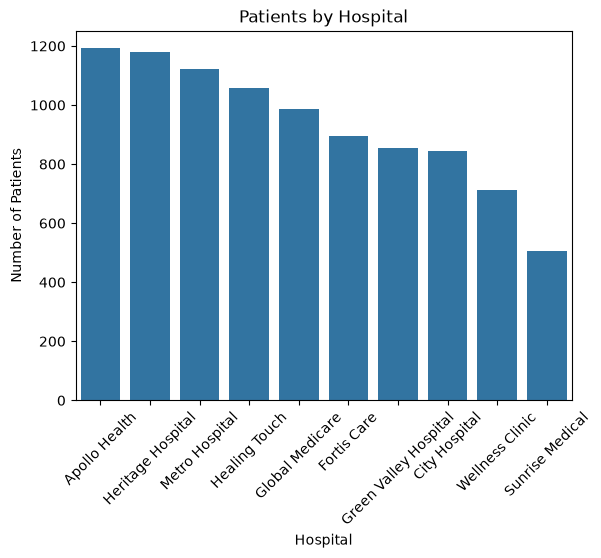

In [42]:
sns.barplot(Hospital_Patients)

plt.title("Patients by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

2.Patients by Department

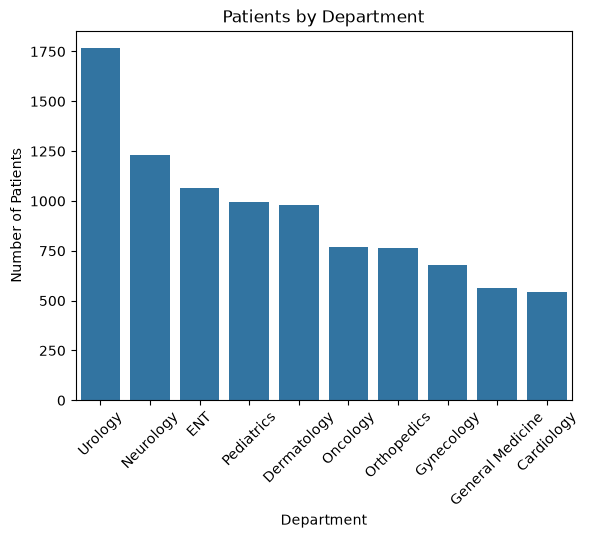

In [43]:
Department_Patients = df.groupby("Department")["Patients Count"].sum()
Department_Patients = Department_Patients.sort_values(ascending=False)
sns.barplot(Department_Patients)
plt.title("Patients by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

3.Medical Expenses by Hospital

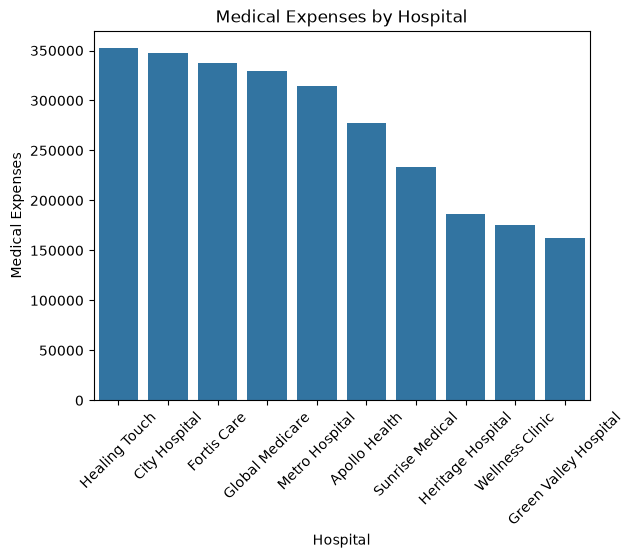

In [44]:
hospital_expenses = df.groupby("Hospital Name")["Medical Expenses"].sum()
hospital_expenses = hospital_expenses.sort_values(ascending=False)

sns.barplot(hospital_expenses)

plt.title("Medical Expenses by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Medical Expenses")
plt.xticks(rotation=45)
plt.show()

4.Doctors vs Patients

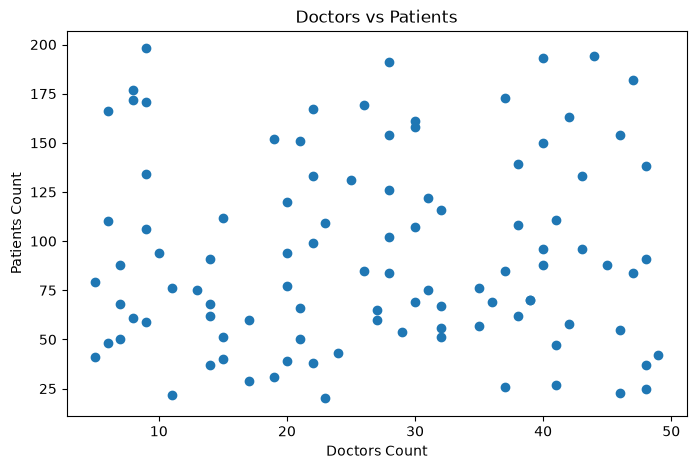

In [45]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Doctors Count"],
    df["Patients Count"]
)

plt.title("Doctors vs Patients")
plt.xlabel("Doctors Count")
plt.ylabel("Patients Count")

plt.show()

5.Patients per Doctor

In [46]:
df["Patients per Doctor"] = (
    df["Patients Count"] / df["Doctors Count"]
)

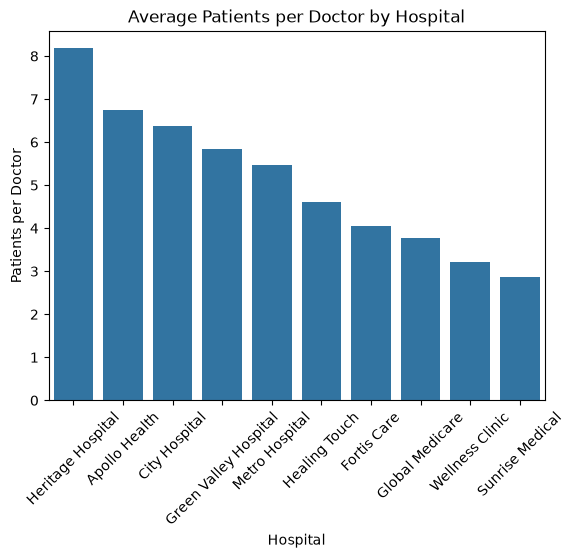

In [47]:
patient_doctor = df.groupby(
    "Hospital Name"
)["Patients per Doctor"].mean()

patient_doctor = patient_doctor.sort_values(
    ascending=False
)

sns.barplot(patient_doctor)

plt.title("Average Patients per Doctor by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Patients per Doctor")
plt.xticks(rotation=45)

plt.show()

6. Length of Stay

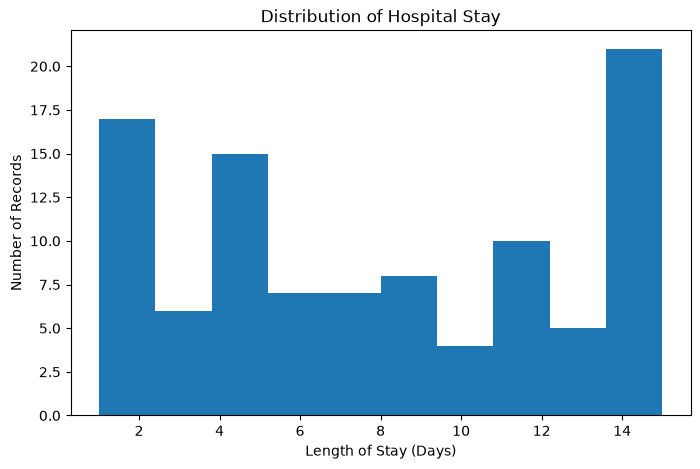

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(df["Length of Stay"], bins=10)

plt.title("Distribution of Hospital Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Records")

plt.show()

7. Admissions Over Time

In [49]:
monthly_admissions = (
    df.groupby(
        df["Admission Date"].dt.to_period("M")
    )["Patients Count"]
    .sum()
)


monthly_admissions.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Patient Admissions Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

## Correlation Heatmap

In [53]:
numeric_columns = [
    "Doctors Count",
    "Patients Count",
    "Medical Expenses",
    "Length of Stay"
]

correlation = df[numeric_columns].corr()

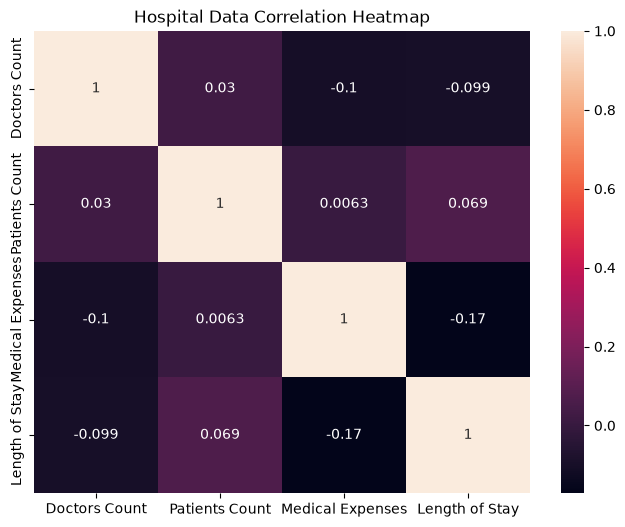

In [54]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Hospital Data Correlation Heatmap")

plt.show()

## KPIs

In [55]:
df["Length of Stay"] = (
    df["Discharge Date"] - df["Admission Date"]
).dt.days


In [56]:
total_hospitals = df["Hospital Name"].nunique()

print("Total Hospitals:", total_hospitals)

Total Hospitals: 10


In [57]:
total_departments = df["Department"].nunique()

In [58]:
total_doctors = df["Doctors Count"].sum()


In [59]:
total_patients = df["Patients Count"].sum()

In [60]:
total_expenses = df["Medical Expenses"].sum()

In [61]:
average_expenses = df["Medical Expenses"].mean()

In [62]:
average_stay = df["Length of Stay"].mean()

kpi_summary = {
    "Total Hospitals": total_hospitals,
    "Total Departments": total_departments,
    "Total Doctors": total_doctors,
    "Total Patients": total_patients,
    "Total Medical Expenses": total_expenses,
    "Average Medical Expenses": average_expenses,
    "Average Length of Stay": average_stay,
}

kpi_summary

## Business Insights

1. Hospital with the Most Patients

In [66]:
hospital_patients = df.groupby(
    "Hospital Name"
)["Patients Count"].sum()

top_hospital = hospital_patients.idxmax()
top_hospital_patients = hospital_patients.max()

print("Hospital with Highest Patients:", top_hospital)
print("Total Patients:", top_hospital_patients)

Hospital with Highest Patients: Apollo Health
Total Patients: 1192


2.Location with the Most Patients

In [68]:
location_patients = df.groupby(
    "Location"
)["Patients Count"].sum()

top_location = location_patients.idxmax()
top_location_patients = location_patients.max()

print("Location with Highest Patients:", top_location)
print("Total Patients:", top_location_patients)

Location with Highest Patients: Jaipur
Total Patients: 1505


3.Hospital with the Highest Medical Expenses

In [69]:
hospital_expenses = df.groupby(
    "Hospital Name"
)["Medical Expenses"].sum()

highest_expense_hospital = hospital_expenses.idxmax()
highest_expense = hospital_expenses.max()

print("Hospital with Highest Expenses:",
      highest_expense_hospital)

print("Total Medical Expenses:",
      highest_expense)

Hospital with Highest Expenses: Healing Touch
Total Medical Expenses: 352178.06


4.Department with the Highest Medical Expenses

In [70]:
department_expenses = df.groupby(
    "Department"
)["Medical Expenses"].sum()

highest_expense_department = department_expenses.idxmax()
highest_department_expense = department_expenses.max()

print("Department with Highest Expenses:",
      highest_expense_department)

print("Total Medical Expenses:",
      highest_department_expense)

Department with Highest Expenses: Urology
Total Medical Expenses: 433418.49


5. Average Length of Hospital Stay

In [71]:
print(
    "Average Length of Stay:",
    round(average_stay, 2),
    "days"
)

Average Length of Stay: 7.95 days
